<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 126.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]


In [2]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-08-26 08:18:48--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  11.3MB/s    in 14s     

2026-08-26 08:19:02 (10.7 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


### Step 2: Import necessary libraries and load the dataset


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

### Load the data


In [5]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [6]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



                   JobSatPoints_6  JobSatPoints_7
Age                                              
18-24 years old              15.0            20.0
25-34 years old              20.0            15.0
35-44 years old              20.0            15.0
45-54 years old              20.0            15.0
55-64 years old              20.0            20.0
65 years or older            20.0            15.0

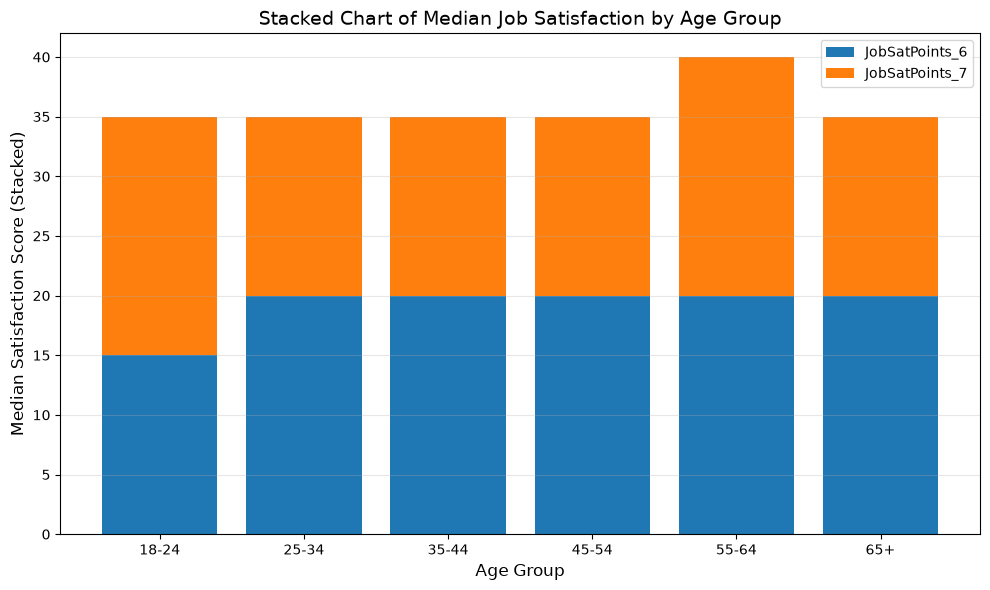

In [9]:
keep_age = [
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

df_age = df[df["Age"].isin(keep_age)].copy()

age_order = [
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]
df_age["Age"] = pd.Categorical(df_age["Age"], categories=age_order, ordered=True)
group_med = df_age.groupby("Age")[["JobSatPoints_6", "JobSatPoints_7"]].median()
print(group_med)
group_med.index = ["18‑24","25‑34","35‑44","45‑54","55‑64","65+"]
fig, ax = plt.subplots(figsize=(10,6))
y6 = group_med["JobSatPoints_6"]
y7 = group_med["JobSatPoints_7"]
ax.bar(group_med.index, y6, label="JobSatPoints_6")
ax.bar(group_med.index, y7, bottom=y6, label="JobSatPoints_7")
ax.set_title("Stacked Chart of Median Job Satisfaction by Age Group", fontsize=14)
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("Median Satisfaction Score (Stacked)", fontsize=12)
ax.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("stacked_jobsat_age.png", dpi=200)
plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


=== Median result ===
                          JobSatPoints_6  JobSatPoints_7
GroupLabel                                              
Freelancer/Self‑employed            15.0            15.0
Full‑time                           20.0            15.0
Part‑time                           15.0            15.0

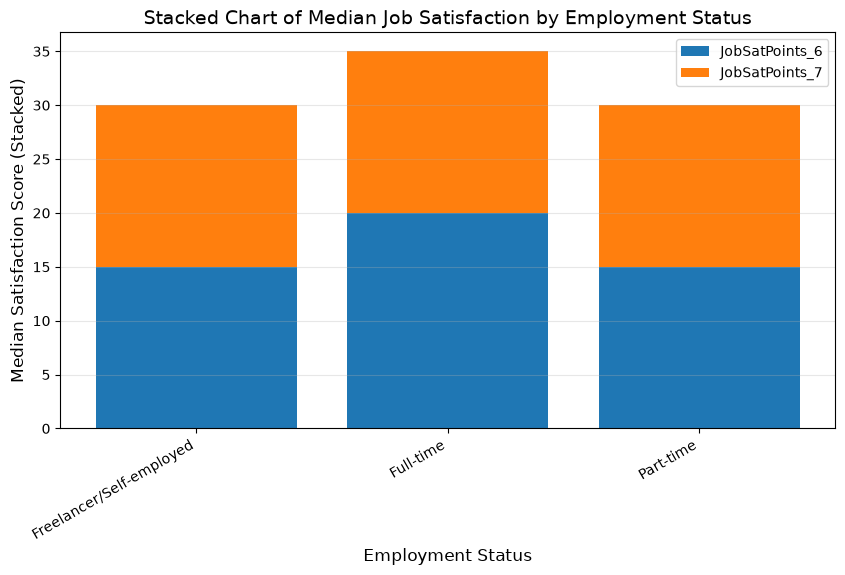

In [18]:
df_emp = df.dropna(subset=["Employment"]).copy()

df_fulltime = df_emp[df_emp["Employment"].str.contains("Employed, full-time", na=False)].copy()
df_parttime = df_emp[df_emp["Employment"].str.contains("Employed, part-time", na=False)].copy()
df_freelance = df_emp[df_emp["Employment"].str.contains("Independent contractor", na=False)].copy()

df_fulltime["GroupLabel"] = "Full‑time"
df_parttime["GroupLabel"] = "Part‑time"
df_freelance["GroupLabel"] = "Freelancer/Self‑employed"

df_combine = pd.concat([df_fulltime, df_parttime, df_freelance])

group_emp = df_combine.groupby("GroupLabel")[["JobSatPoints_6", "JobSatPoints_7"]].median()
print("=== Median result ===")
print(group_emp)

fig, ax = plt.subplots(figsize=(10, 6))
y6 = group_emp["JobSatPoints_6"]
y7 = group_emp["JobSatPoints_7"]
ax.bar(group_emp.index, y6, label="JobSatPoints_6")
ax.bar(group_emp.index, y7, bottom=y6, label="JobSatPoints_7")
ax.set_title("Stacked Chart of Median Job Satisfaction by Employment Status", fontsize=14)
ax.set_xlabel("Employment Status", fontsize=12)
ax.set_ylabel("Median Satisfaction Score (Stacked)", fontsize=12)
plt.xticks(rotation=30, ha="right")
ax.legend()
plt.grid(axis="y", alpha=0.3)
plt.subplots_adjust(bottom=0.22)
plt.savefig("stacked_jobsat_employment_clean.png", dpi=200)
plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


篩選後樣本數：11808

=== Age group median result ===
                 ConvertedCompYearly  JobSatPoints_6
Age                                                 
25-34 years old              59872.0            20.0
35-44 years old              85925.0            20.0

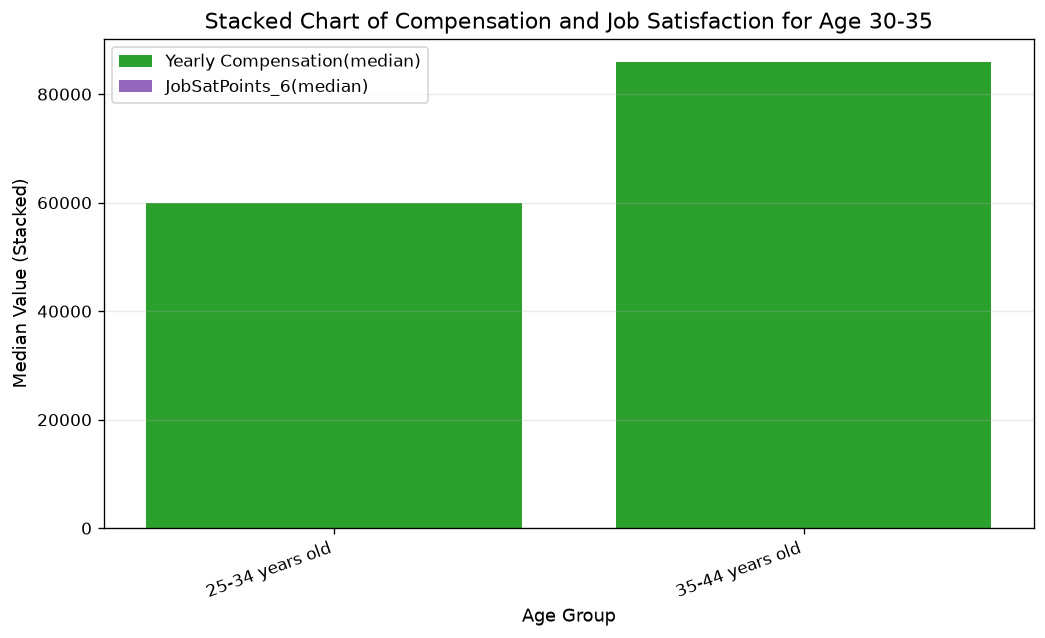

In [21]:
age_target = ["25-34 years old", "35-44 years old"]
df_age = df[df["Age"].isin(age_target)].copy()

df_age = df_age.dropna(subset=["ConvertedCompYearly", "JobSatPoints_6"])
print(f"篩選後樣本數：{len(df_age)}")

group_age = df_age.groupby("Age")[["ConvertedCompYearly", "JobSatPoints_6"]].median()
print("\n=== Age group median result ===")
print(group_age)

fig, ax = plt.subplots(figsize=(10,6), dpi=120)
y_comp = group_age["ConvertedCompYearly"]
y_sat = group_age["JobSatPoints_6"]
ax.bar(group_age.index, y_comp, label="Yearly Compensation(median)", color="#2ca02c")
ax.bar(group_age.index, y_sat, bottom=y_comp, label="JobSatPoints_6(median)", color="#9467bd")
ax.set_title("Stacked Chart of Compensation and Job Satisfaction for Age 30‑35", fontsize=13)
ax.set_xlabel("Age Group", fontsize=11)
ax.set_ylabel("Median Value (Stacked)", fontsize=11)
plt.xticks(rotation=20, ha="right")
ax.legend()
plt.grid(axis="y", alpha=0.25)
plt.subplots_adjust(bottom=0.2)
plt.savefig("stacked_age_comp_sat.png", dpi=150, bbox_inches="tight")
plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


=== 各年齡層中位薪酬、工作滿意度 ===
                    ConvertedCompYearly  JobSatPoints_6
Age                                                    
18-24 years old                 25735.0            20.0
25-34 years old                 59872.0            20.0
35-44 years old                 85925.0            20.0
45-54 years old                100900.5            20.0
55-64 years old                119189.5            20.0
65 years or older              121668.0            20.0
Prefer not to say              133023.5            15.0
Under 18 years old               8661.0            10.0

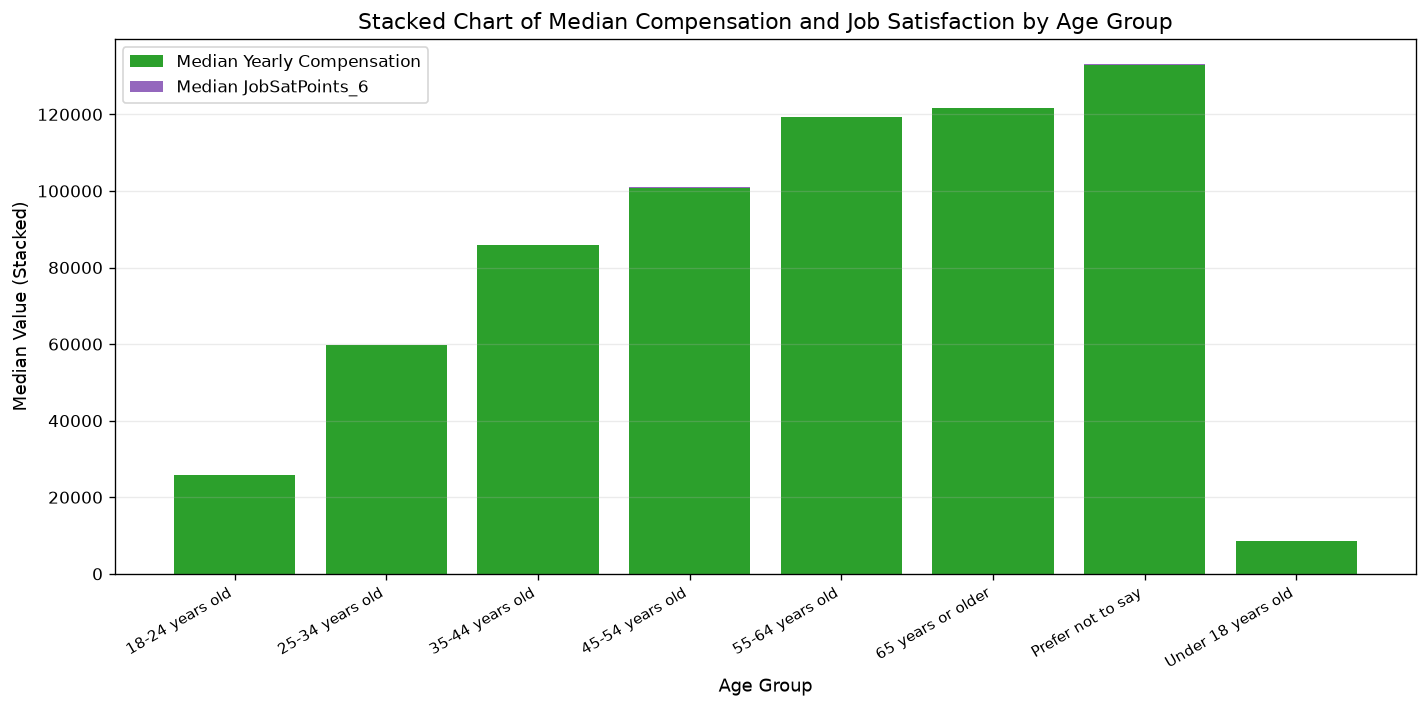

In [22]:
df_age_all = df.dropna(subset=["Age", "ConvertedCompYearly", "JobSatPoints_6"]).copy()

group_all_age = df_age_all.groupby("Age")[["ConvertedCompYearly", "JobSatPoints_6"]].median()
print("=== 各年齡層中位薪酬、工作滿意度 ===")
print(group_all_age)

fig, ax = plt.subplots(figsize=(12,6), dpi=120)
y_comp = group_all_age["ConvertedCompYearly"]
y_sat = group_all_age["JobSatPoints_6"]
ax.bar(group_all_age.index, y_comp, label="Median Yearly Compensation", color="#2ca02c")
ax.bar(group_all_age.index, y_sat, bottom=y_comp, label="Median JobSatPoints_6", color="#9467bd")
ax.set_title("Stacked Chart of Median Compensation and Job Satisfaction by Age Group", fontsize=13)
ax.set_xlabel("Age Group", fontsize=11)
ax.set_ylabel("Median Value (Stacked)", fontsize=11)
plt.xticks(rotation=30, ha="right", fontsize=9)
ax.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig("stacked_all_age_comp_sat.png", dpi=150, bbox_inches="tight")
plt.show()

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


In [23]:
df_db = df.dropna(subset=["Age", "DatabaseWantToLearn"]).copy()
df_db["DatabaseWantToLearn"] = df_db["DatabaseWantToLearn"].str.split(";")
df_explode = df_db.explode("DatabaseWantToLearn")

count_df = df_explode.groupby(["Age", "DatabaseWantToLearn"]).size().unstack(fill_value=0)
print("=== 各年齡層想學習資料庫原始計數 ===")
print(count_df)

pct_df = count_df.div(count_df.sum(axis=1), axis=0)
plt.figure(figsize=(14,7), dpi=120)
ax = pct_df.plot(kind="bar", stacked=True, figsize=(14,7), colormap="tab20", ax=plt.gca())
ax.set_title("Stacked Chart: Database Want To Learn by Age Group", fontsize=14)
ax.set_xlabel("Age Group", fontsize=11)
ax.set_ylabel("Percentage within Age Group (100%)", fontsize=11)
plt.xticks(rotation=35, ha="right", fontsize=9)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig("stacked_db_want_learn_age.png", dpi=150, bbox_inches="tight")
plt.show()

KeyError: ['DatabaseWantToLearn']

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


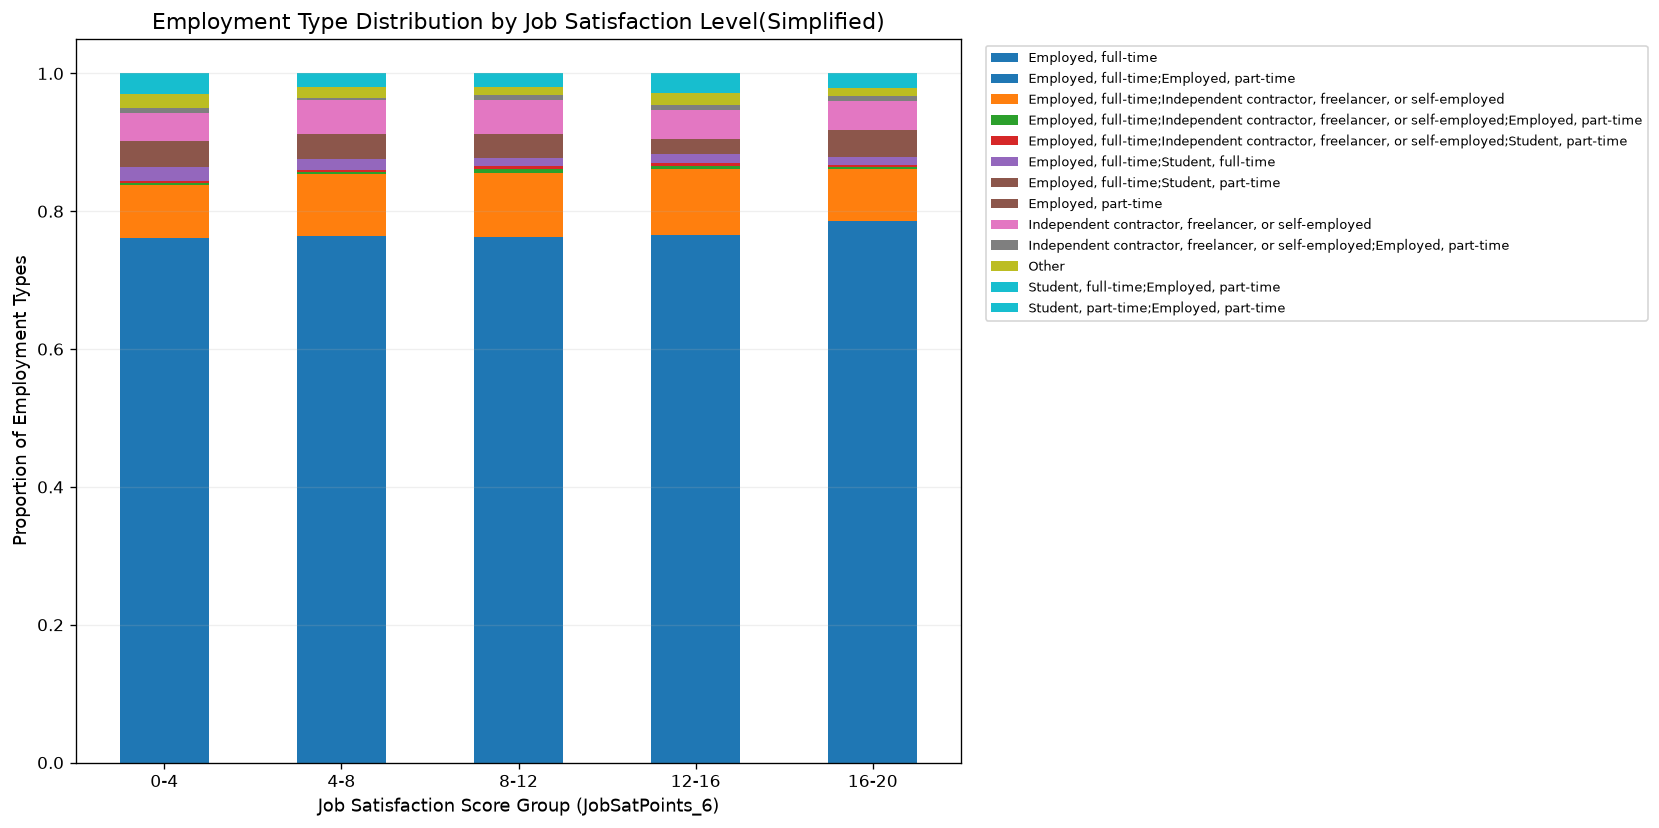

In [28]:
df_plot = df.dropna(subset=["JobSatPoints_6", "Employment"]).copy()

bins = [0,4,8,12,16,20]
labels = ["0‑4", "4‑8", "8‑12", "12‑16", "16‑20"]
df_plot["Sat_Group"] = pd.cut(df_plot["JobSatPoints_6"], bins=bins, labels=labels, include_lowest=True)

top_types = df_plot["Employment"].value_counts().head(12).index.tolist()
df_plot["Employment_Simplified"] = df_plot["Employment"].where(
    df_plot["Employment"].isin(top_types), other="Other"
)

ct = pd.crosstab(df_plot["Sat_Group"], df_plot["Employment_Simplified"])
ct_pct = ct.div(ct.sum(axis=1), axis=0)

plt.figure(figsize=(14,7), dpi=120)
ax = ct_pct.plot(kind="bar", stacked=True, figsize=(14,7), colormap="tab10", ax=plt.gca())
ax.set_title("Employment Type Distribution by Job Satisfaction Level(Simplified)", fontsize=13)
ax.set_xlabel("Job Satisfaction Score Group (JobSatPoints_6)", fontsize=11)
ax.set_ylabel("Proportion of Employment Types", fontsize=11)
plt.xticks(rotation=0, ha="center", fontsize=10)
ax.legend(bbox_to_anchor=(1.02,1), loc="upper left", fontsize=8)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig("employment_by_jobsat_fixed.png", dpi=150, bbox_inches="tight")
plt.show()

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


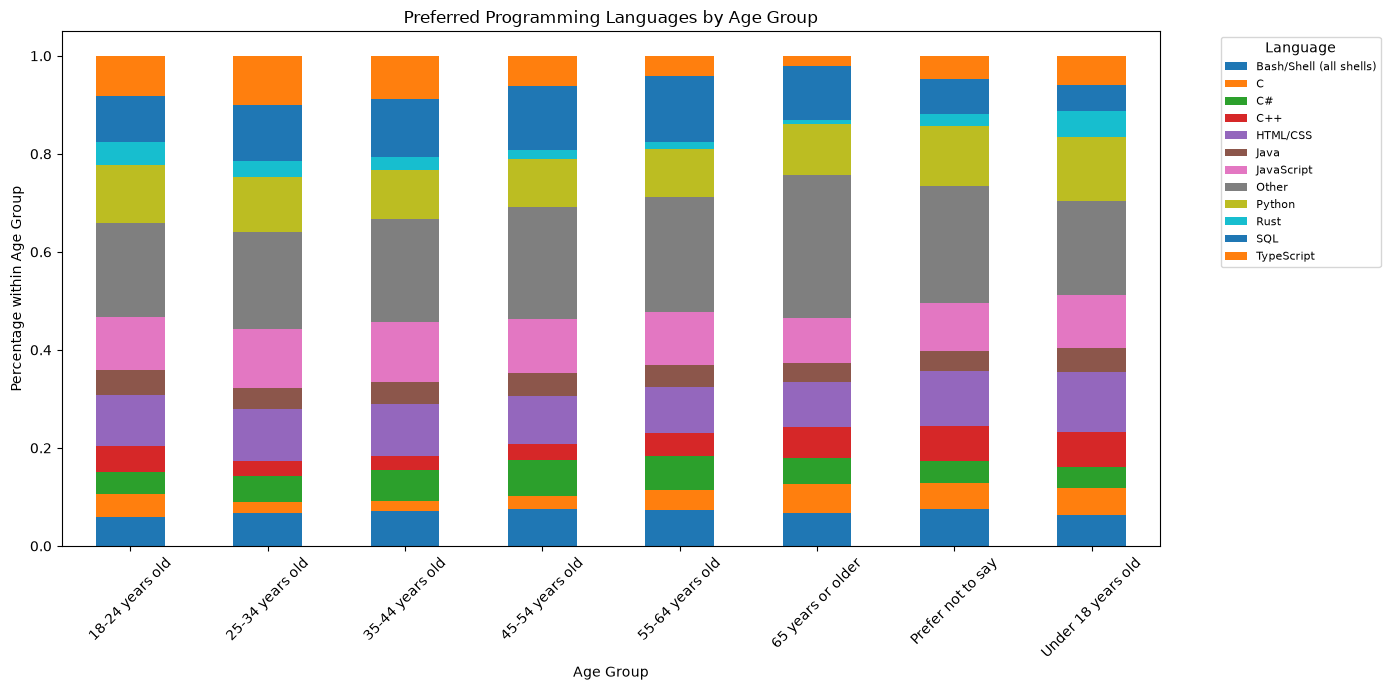

In [29]:
df_lang = df.dropna(subset=["Age", "LanguageAdmired"]).copy()
df_lang["LanguageAdmired"] = df_lang["LanguageAdmired"].str.split(";")
df_lang_exploded = df_lang.explode("LanguageAdmired")

top_langs = df_lang_exploded["LanguageAdmired"].value_counts().head(11).index
df_lang_exploded["Lang_Simple"] = df_lang_exploded["LanguageAdmired"].where(
    df_lang_exploded["LanguageAdmired"].isin(top_langs), other="Other"
)

lang_counts = (df_lang_exploded.groupby(["Age", "Lang_Simple"]).size().unstack(fill_value=0))
lang_props = lang_counts.div(lang_counts.sum(axis=1), axis=0)
lang_props.plot(kind="bar", stacked=True, figsize=(14,7))

plt.xlabel("Age Group")
plt.ylabel("Percentage within Age Group")
plt.title("Preferred Programming Languages by Age Group")
plt.xticks(rotation=45)
plt.legend(title="Language", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


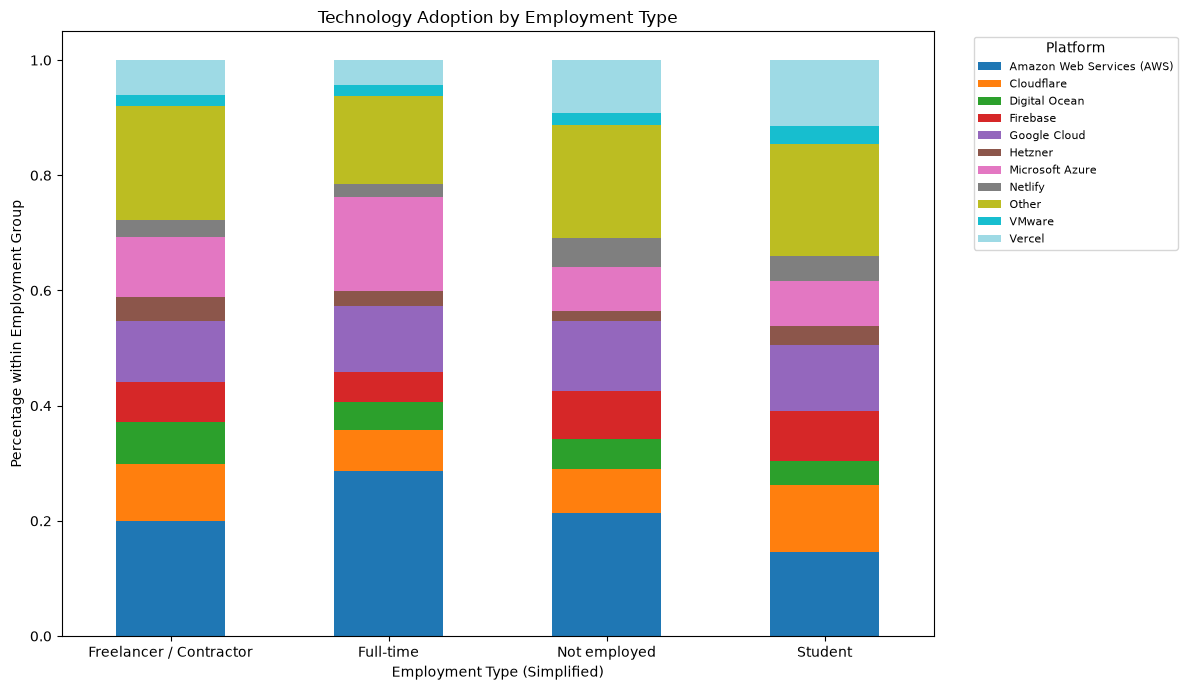

In [31]:
df_em = df.dropna(subset=["Employment", "PlatformAdmired"]).copy()

def simplify_employment(text):
    text = text.lower()
    if "independent contractor" in text:
        return "Freelancer / Contractor"
    elif "part‑time" in text:
        return "Part‑time"
    elif "student" in text:
        return "Student"
    elif "not employed" in text:
        return "Not employed"
    else:
        return "Full‑time"

df_em["Emp_Simple"] = df_em["Employment"].apply(simplify_employment)
df_em["PlatformAdmired"] = df_em["PlatformAdmired"].str.split(";")
df_em_exploded = df_em.explode("PlatformAdmired")

top_plat = df_em_exploded["PlatformAdmired"].value_counts().head(10).index
df_em_exploded["Plat_Simple"] = df_em_exploded["PlatformAdmired"].where(
    df_em_exploded["PlatformAdmired"].isin(top_plat), other="Other"
)
em_counts = df_em_exploded.groupby(["Emp_Simple", "Plat_Simple"]).size().unstack(fill_value=0)
em_props = em_counts.div(em_counts.sum(axis=1), axis=0)
em_props.plot(kind="bar", stacked=True, figsize=(12,7), colormap="tab20")
plt.xlabel("Employment Type (Simplified)")
plt.ylabel("Percentage within Employment Group")
plt.title("Technology Adoption by Employment Type")
plt.xticks(rotation=0, ha="center", fontsize=10)
plt.legend(title="Platform", bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("stacked_platform_employment_fixed.png", dpi=150, bbox_inches="tight")
plt.show()

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
